In [1]:
# coding: utf-8
import sys
sys.path.append('../..')
import numpy as np
import matplotlib.pyplot as plt
from dataset import sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq
from seq2seq import Seq2seq
from peeky_seq2seq import PeekySeq2seq

# Base

In [10]:
# 데이터셋 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
char_to_id, id_to_char = sequence.get_vocab()

# 입력 반전 여부 설정 =============================================
is_reverse = False  # True
if is_reverse:
    x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
# ================================================================

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# 일반 혹은 엿보기(Peeky) 설정 =====================================
model = Seq2seq(vocab_size, wordvec_size, hidden_size)
# model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
# ================================================================
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('검증 정확도 %.3f%%' % (acc * 100))
base_x = np.arange(len(acc_list))
base_acc = acc_list


| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 2.56
| 에폭 1 |  반복 21 / 351 | 시간 0[s] | 손실 2.53
| 에폭 1 |  반복 41 / 351 | 시간 0[s] | 손실 2.17
| 에폭 1 |  반복 61 / 351 | 시간 0[s] | 손실 1.96
| 에폭 1 |  반복 81 / 351 | 시간 0[s] | 손실 1.92
| 에폭 1 |  반복 101 / 351 | 시간 0[s] | 손실 1.87
| 에폭 1 |  반복 121 / 351 | 시간 0[s] | 손실 1.85
| 에폭 1 |  반복 141 / 351 | 시간 0[s] | 손실 1.83
| 에폭 1 |  반복 161 / 351 | 시간 0[s] | 손실 1.79
| 에폭 1 |  반복 181 / 351 | 시간 0[s] | 손실 1.77
| 에폭 1 |  반복 201 / 351 | 시간 0[s] | 손실 1.77
| 에폭 1 |  반복 221 / 351 | 시간 1[s] | 손실 1.76
| 에폭 1 |  반복 241 / 351 | 시간 1[s] | 손실 1.76
| 에폭 1 |  반복 261 / 351 | 시간 1[s] | 손실 1.76
| 에폭 1 |  반복 281 / 351 | 시간 1[s] | 손실 1.75
| 에폭 1 |  반복 301 / 351 | 시간 1[s] | 손실 1.74
| 에폭 1 |  반복 321 / 351 | 시간 1[s] | 손실 1.75
| 에폭 1 |  반복 341 / 351 | 시간 1[s] | 손실 1.74
Q 77+85  
T 162 
☒ 100 
---
Q 975+164
T 1139
☒ 1000
---
Q 582+84 
T 666 
☒ 1000
---
Q 8+155  
T 163 
☒ 100 
---
Q 367+55 
T 422 
☒ 1000
---
Q 600+257
T 857 
☒ 1000
---
Q 761+292
T 1053
☒ 1000
---
Q 830+597
T 1427
☒ 1000
---
Q 26+838

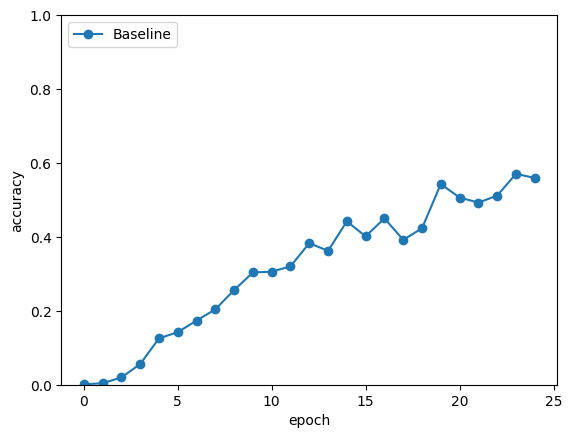

In [13]:
x = np.arange(len(acc_list))
plt.plot(x, acc_list, marker='o', label='Baseline')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.ylim(0, 1.0)
plt.legend(loc='upper left')
plt.show()

# Reverse

In [11]:
# 데이터셋 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
char_to_id, id_to_char = sequence.get_vocab()

# 입력 반전 여부 설정 =============================================
is_reverse = False  # True
if is_reverse:
    x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
# ================================================================

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# 일반 혹은 엿보기(Peeky) 설정 =====================================
model = Seq2seq(vocab_size, wordvec_size, hidden_size)
# model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
# ================================================================
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('검증 정확도 %.3f%%' % (acc * 100))
reverse_x = np.arange(len(acc_list))
reverse_acc = acc_list


| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 2.56
| 에폭 1 |  반복 21 / 351 | 시간 0[s] | 손실 2.52
| 에폭 1 |  반복 41 / 351 | 시간 0[s] | 손실 2.17
| 에폭 1 |  반복 61 / 351 | 시간 0[s] | 손실 1.96
| 에폭 1 |  반복 81 / 351 | 시간 0[s] | 손실 1.91
| 에폭 1 |  반복 101 / 351 | 시간 0[s] | 손실 1.87
| 에폭 1 |  반복 121 / 351 | 시간 0[s] | 손실 1.86
| 에폭 1 |  반복 141 / 351 | 시간 0[s] | 손실 1.84
| 에폭 1 |  반복 161 / 351 | 시간 0[s] | 손실 1.80
| 에폭 1 |  반복 181 / 351 | 시간 0[s] | 손실 1.78
| 에폭 1 |  반복 201 / 351 | 시간 1[s] | 손실 1.77
| 에폭 1 |  반복 221 / 351 | 시간 1[s] | 손실 1.77
| 에폭 1 |  반복 241 / 351 | 시간 1[s] | 손실 1.76
| 에폭 1 |  반복 261 / 351 | 시간 1[s] | 손실 1.75
| 에폭 1 |  반복 281 / 351 | 시간 1[s] | 손실 1.74
| 에폭 1 |  반복 301 / 351 | 시간 1[s] | 손실 1.74
| 에폭 1 |  반복 321 / 351 | 시간 1[s] | 손실 1.74
| 에폭 1 |  반복 341 / 351 | 시간 1[s] | 손실 1.73
Q   58+77
T 162 
☒ 100 
---
Q 461+579
T 1139
☒ 1000
---
Q  48+285
T 666 
☒ 1001
---
Q   551+8
T 163 
☒ 100 
---
Q  55+763
T 422 
☒ 1001
---
Q 752+006
T 857 
☒ 1000
---
Q 292+167
T 1053
☒ 1000
---
Q 795+038
T 1427
☒ 1000
---
Q  838+6

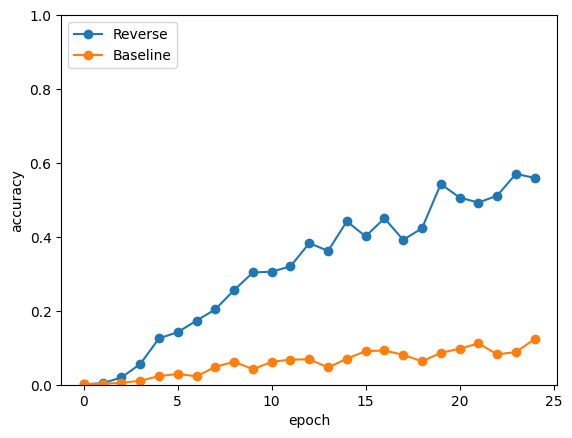

In [12]:
plt.plot(reverse_x, reverse_acc, marker='o', label='Reverse')
plt.plot(base_x, base_acc, marker='o', label='Baseline')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.ylim(0, 1.0)
plt.legend(loc='upper left')
plt.show()

In [14]:
# 데이터셋 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
# x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
char_to_id, id_to_char = sequence.get_vocab()

# 입력 반전 여부 설정 =============================================
is_reverse = False  # True
if is_reverse:
    x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
# ================================================================

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# 일반 혹은 엿보기(Peeky) 설정 =====================================
# model = Seq2seq(vocab_size, wordvec_size, hidden_size)
model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
# ================================================================
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('검증 정확도 %.3f%%' % (acc * 100))
peeky_x = np.arange(len(acc_list))
peeky_acc = acc_list


| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 2.57
| 에폭 1 |  반복 21 / 351 | 시간 0[s] | 손실 2.49
| 에폭 1 |  반복 41 / 351 | 시간 0[s] | 손실 2.20
| 에폭 1 |  반복 61 / 351 | 시간 0[s] | 손실 1.97
| 에폭 1 |  반복 81 / 351 | 시간 0[s] | 손실 1.84
| 에폭 1 |  반복 101 / 351 | 시간 0[s] | 손실 1.80
| 에폭 1 |  반복 121 / 351 | 시간 0[s] | 손실 1.79
| 에폭 1 |  반복 141 / 351 | 시간 0[s] | 손실 1.77
| 에폭 1 |  반복 161 / 351 | 시간 0[s] | 손실 1.77
| 에폭 1 |  반복 181 / 351 | 시간 0[s] | 손실 1.76
| 에폭 1 |  반복 201 / 351 | 시간 1[s] | 손실 1.76
| 에폭 1 |  반복 221 / 351 | 시간 1[s] | 손실 1.75
| 에폭 1 |  반복 241 / 351 | 시간 1[s] | 손실 1.76
| 에폭 1 |  반복 261 / 351 | 시간 1[s] | 손실 1.75
| 에폭 1 |  반복 281 / 351 | 시간 1[s] | 손실 1.74
| 에폭 1 |  반복 301 / 351 | 시간 1[s] | 손실 1.73
| 에폭 1 |  반복 321 / 351 | 시간 1[s] | 손실 1.73
| 에폭 1 |  반복 341 / 351 | 시간 1[s] | 손실 1.73
Q 77+85  
T 162 
☒ 107 
---
Q 975+164
T 1139
☒ 1011
---
Q 582+84 
T 666 
☒ 103 
---
Q 8+155  
T 163 
☒ 101 
---
Q 367+55 
T 422 
☒ 103 
---
Q 600+257
T 857 
☒ 1023
---
Q 761+292
T 1053
☒ 1023
---
Q 830+597
T 1427
☒ 1011
---
Q 26+838

In [ ]:
# 데이터셋 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('addition.txt')
x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
char_to_id, id_to_char = sequence.get_vocab()

# 입력 반전 여부 설정 =============================================
is_reverse = False  # True
if is_reverse:
    x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]
# ================================================================

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# 일반 혹은 엿보기(Peeky) 설정 =====================================
# model = Seq2seq(vocab_size, wordvec_size, hidden_size)
model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
# ================================================================
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('검증 정확도 %.3f%%' % (acc * 100))
peeky_reverse_x = np.arange(len(acc_list))
peeky_reverse_acc = acc_list


| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 2.57
| 에폭 1 |  반복 21 / 351 | 시간 0[s] | 손실 2.48
| 에폭 1 |  반복 41 / 351 | 시간 0[s] | 손실 2.20
| 에폭 1 |  반복 61 / 351 | 시간 0[s] | 손실 1.99
| 에폭 1 |  반복 81 / 351 | 시간 0[s] | 손실 1.89
| 에폭 1 |  반복 101 / 351 | 시간 0[s] | 손실 1.82
| 에폭 1 |  반복 121 / 351 | 시간 0[s] | 손실 1.81
| 에폭 1 |  반복 141 / 351 | 시간 0[s] | 손실 1.79
| 에폭 1 |  반복 161 / 351 | 시간 0[s] | 손실 1.78
| 에폭 1 |  반복 181 / 351 | 시간 0[s] | 손실 1.77
| 에폭 1 |  반복 201 / 351 | 시간 1[s] | 손실 1.77
| 에폭 1 |  반복 221 / 351 | 시간 1[s] | 손실 1.76
| 에폭 1 |  반복 241 / 351 | 시간 1[s] | 손실 1.76
| 에폭 1 |  반복 261 / 351 | 시간 1[s] | 손실 1.75
| 에폭 1 |  반복 281 / 351 | 시간 1[s] | 손실 1.74
| 에폭 1 |  반복 301 / 351 | 시간 1[s] | 손실 1.74
| 에폭 1 |  반복 321 / 351 | 시간 1[s] | 손실 1.73
| 에폭 1 |  반복 341 / 351 | 시간 1[s] | 손실 1.72
Q   58+77
T 162 
☒ 100 
---
Q 461+579
T 1139
☒ 1011
---
Q  48+285
T 666 
☒ 102 
---
Q   551+8
T 163 
☒ 100 
---
Q  55+763
T 422 
☒ 1023
---
Q 752+006
T 857 
☒ 1023
---
Q 292+167
T 1053
☒ 1023
---
Q 795+038
T 1427
☒ 1111
---
Q  838+6

In [ ]:
plt.plot(base_x, base_acc, marker='o', label='Baseline')
plt.plot(reverse_x, reverse_acc, marker='o', label='Reverse')
plt.plot(peeky_x, peeky_acc, marker='o', label='Peeky')
plt.plot(peeky_reverse_x, peeky_reverse_acc, marker='o', label='Peeky Reverse')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.ylim(0, 1.0)
plt.legend(loc='upper left')
plt.show()